In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

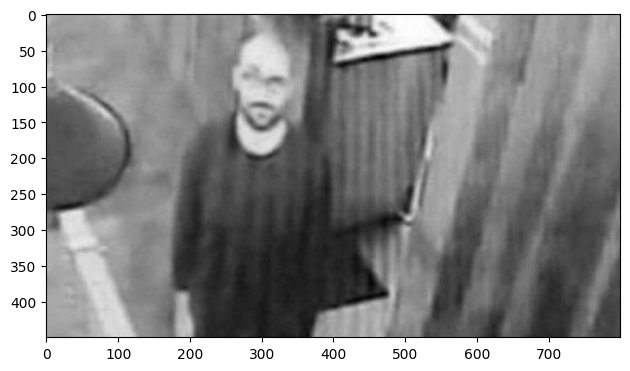

In [19]:
img1= cv2.imread('backup.jpg', cv2.IMREAD_GRAYSCALE)

plt.imshow(img1, cmap='gray')
plt.tight_layout()
plt.show()

In [ ]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img, dtype=np.float32)
    height, width = img.shape
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

In [ ]:
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])
kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

smoothed = convolution(img1, kernelSmoothing)
sharpened = convolution(img1, kernelSharpening)

min_val = sharpened[0, 0]
max_val = sharpened[0, 0]

for i in range(sharpened.shape[0]):
    for j in range(sharpened.shape[1]):

        if sharpened[i, j] < min_val:
            min_val = sharpened[i, j]

        if sharpened[i, j] > max_val:
            max_val = sharpened[i, j]

for i in range(sharpened.shape[0]):
    for j in range(sharpened.shape[1]):

        sharpened[i, j] = ((sharpened[i, j] - min_val) / (max_val - min_val)) * 255

for i in range(smoothed.shape[0]):
    for j in range(smoothed.shape[1]):

        if smoothed[i, j] < 0:
            smoothed[i, j] = 0

        elif smoothed[i, j] > 255:
            smoothed[i, j] = 255

smoothed = smoothed.astype(np.uint8)
sharpened = sharpened.astype(np.uint8)

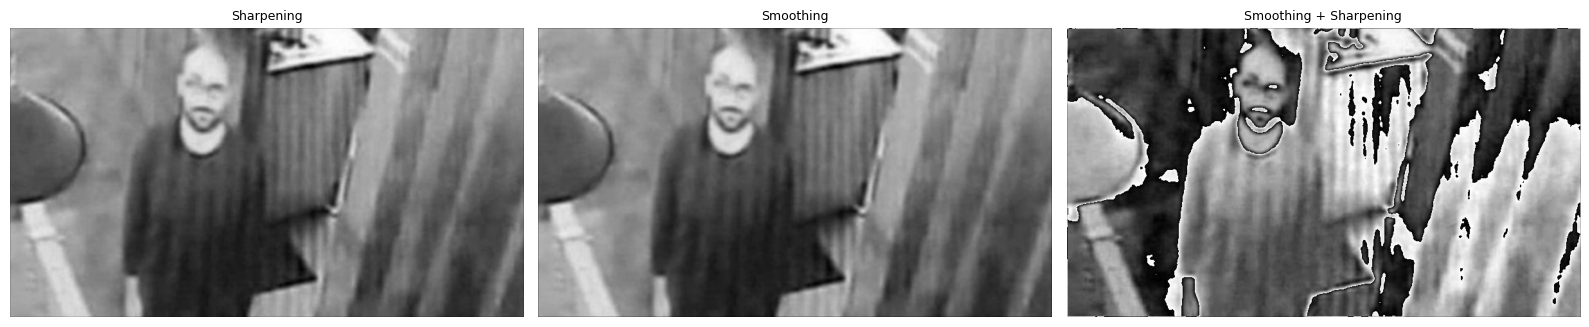

In [25]:
titles = [
    'Sharpening', 'Smoothing', 'Smoothing + Sharpening'
]
comb = sharpened + smoothed
images = [sharpened, smoothed, comb]

fig, axes = plt.subplots(1, 3, figsize=(16, 8))
for ax, img, title in zip(axes.ravel(), images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobelY = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)

prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewittY = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32)

robertsX = np.array([
    [1,  0],
    [0, -1]
], dtype=np.float32)

robertsY = np.array([
    [ 0, 1],
    [-1, 0]
], dtype=np.float32)

In [ ]:
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

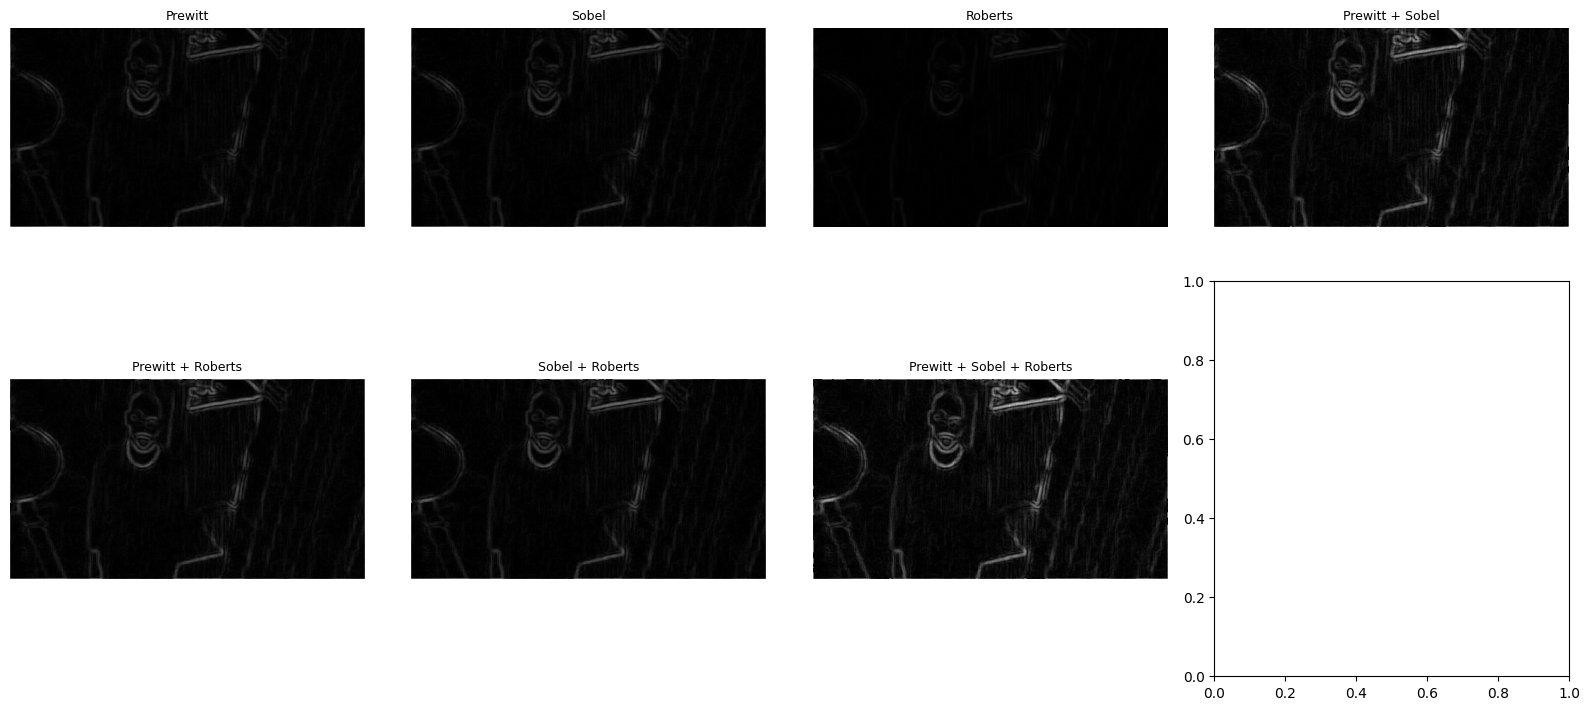

In [28]:
Prewitt = edge(img1, prewittX, prewittY)
Sobel = edge(img1, sobelX, sobelY)
Robert = edge(img1, robertsX, robertsY)

comb1 = Prewitt + Sobel
comb2 = Prewitt + Robert
comb3 = Sobel + Robert
comb4 = Prewitt + Sobel + Robert

titles = [ 'Prewitt', 'Sobel', 'Roberts', 'Prewitt + Sobel', 'Prewitt + Roberts',
       'Sobel + Roberts', 'Prewitt + Sobel + Roberts'
]

images = [Prewitt, Sobel, Robert, comb1, comb2, comb3, comb4]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, img, title in zip(axes.ravel(), images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

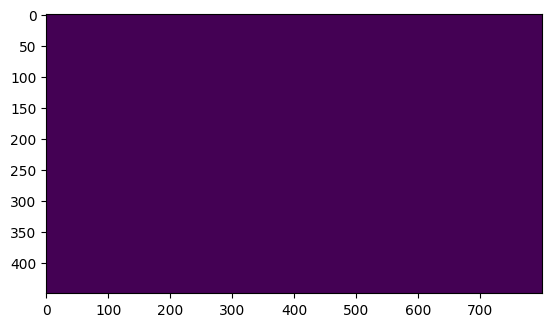

In [38]:
def thresholds(img, threshold=50):
    h, w = img.shape[:2]
    hasil = np.zeros_like(img, dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            hasil[i, j] = 255 if img[i, j] > threshold else 0
                
    return hasil

cctv1 = thresholds(img1, 10)
plt.imshow(cctv1)
plt.show()


Text(0.5, 1.0, 'david grayscale')

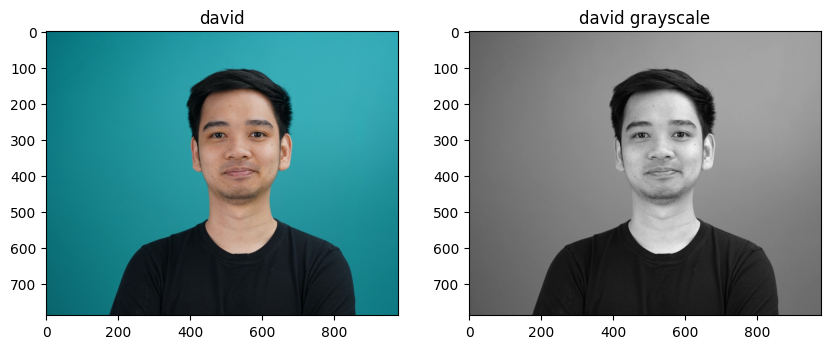

In [18]:
img2 = cv2.imread('david.jpg', cv2.IMREAD_COLOR_RGB)
gray = cv2.cvtColor(np.array(img2, dtype=np.uint8), cv2.COLOR_RGB2GRAY) 

_, (a, b) = plt.subplots(1, 2, figsize=(10, 10))
a.imshow(img2); a.set_title("david")
b.imshow(gray, cmap='gray'); b.set_title("david grayscale")

In [ ]:
david1 = edge(gray, )